Dataset Shape: (200, 5)

First 5 rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   41                 100                      42
1           2  Female   69                  71                       9
2           3  Female   28                  43                      50
3           4  Female   66                  92                      27
4           5    Male   25                 106                      66

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int32 
 3   Annual Income (k$)      200 non-null    int32 
 4   Spending Score (1-100)  200 non-null    int32 
dtypes: int32(3), int64(1), object(1)

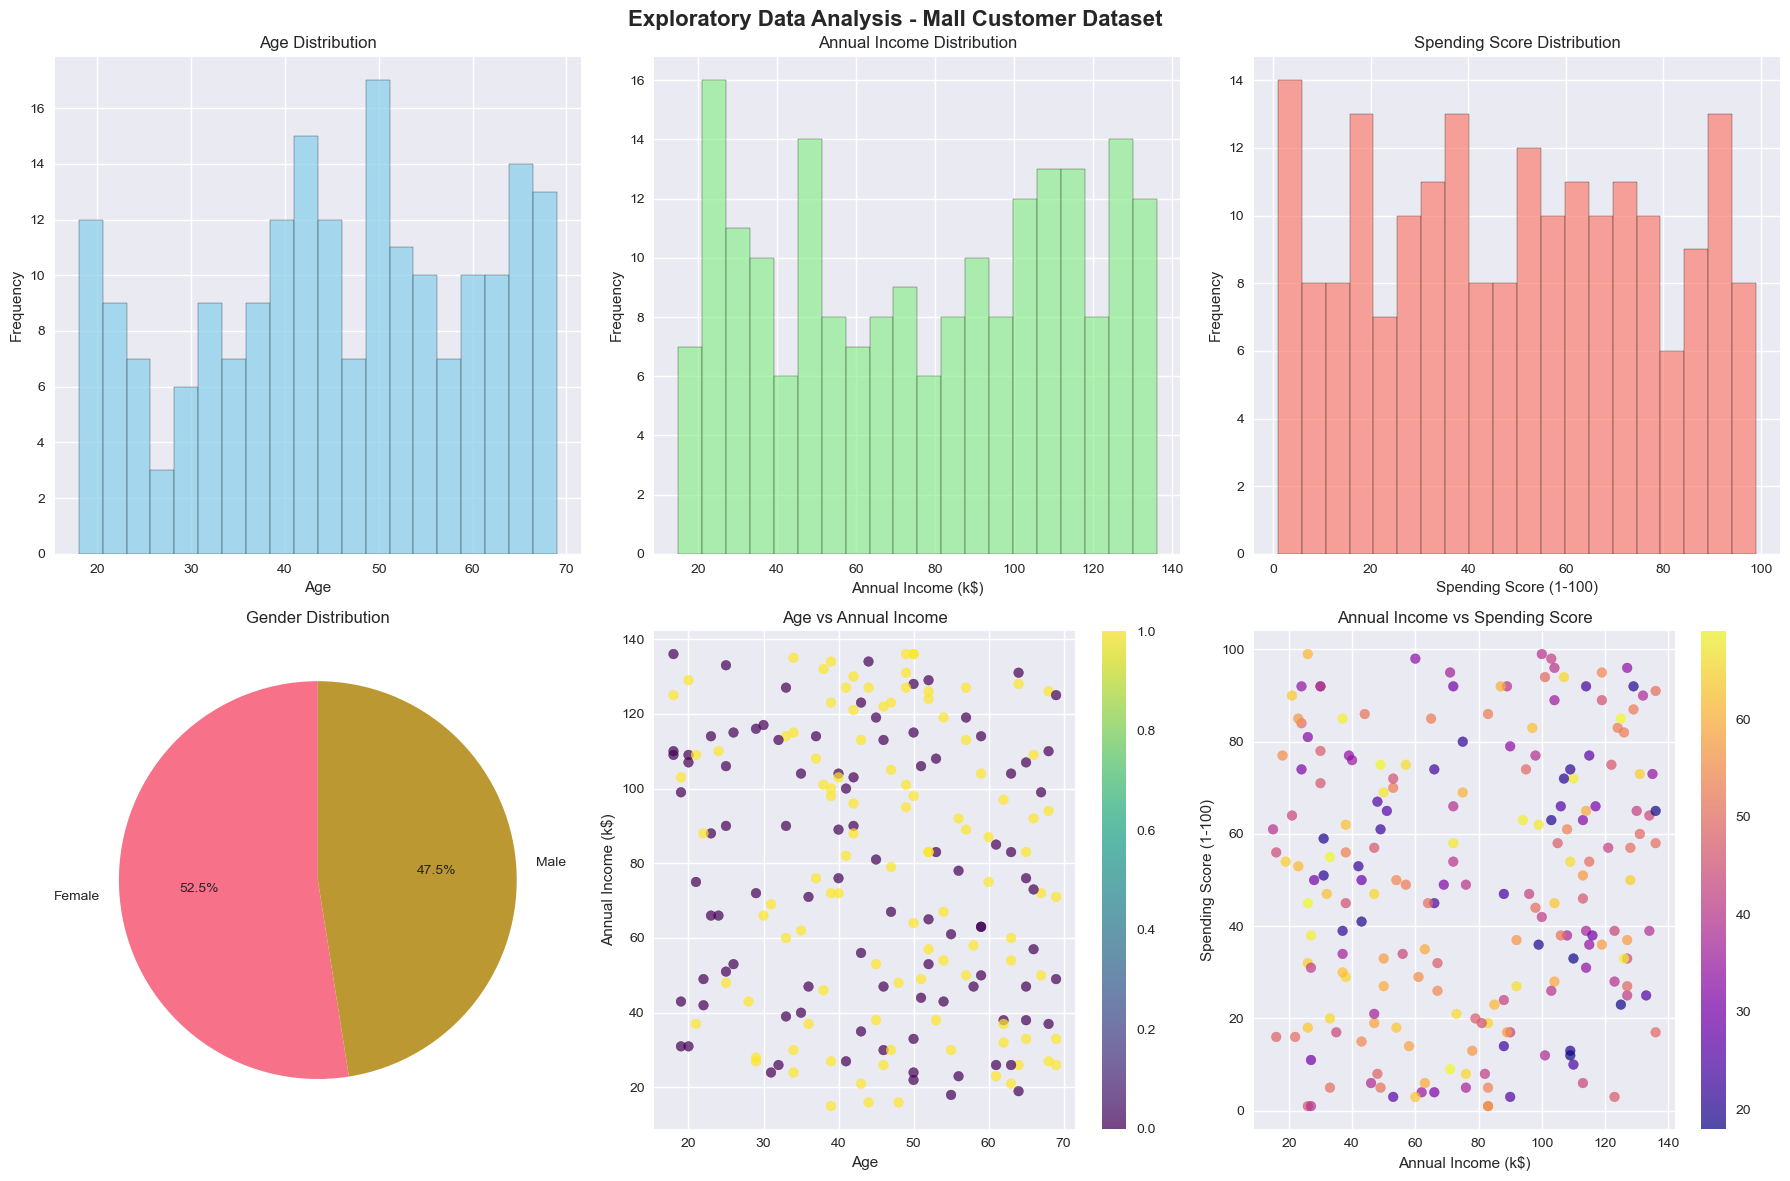


Correlation Matrix:
                     Age  Annual_Income  Spending_Score  Gender_Encoded
Age             1.000000      -0.129960       -0.045514        0.114512
Annual_Income  -0.129960       1.000000        0.086895        0.035595
Spending_Score -0.045514       0.086895        1.000000       -0.131773
Gender_Encoded  0.114512       0.035595       -0.131773        1.000000


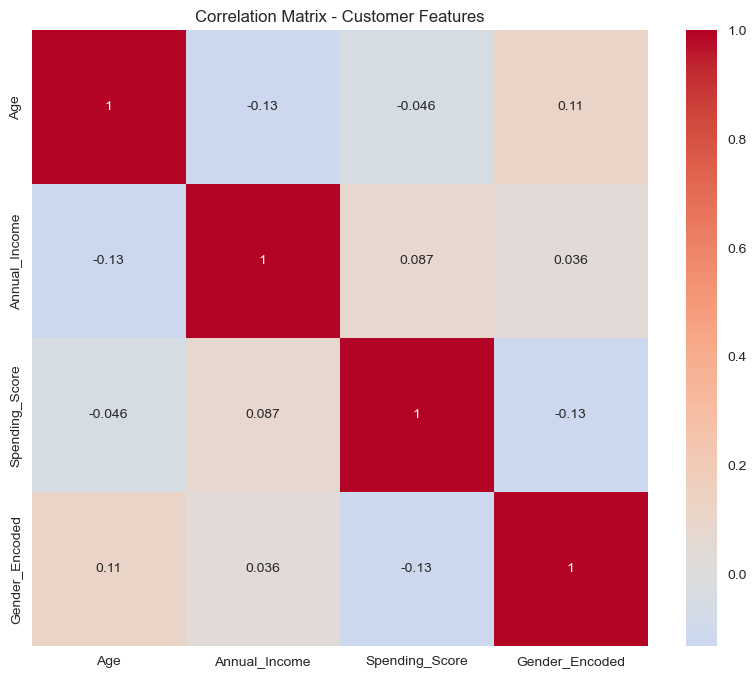

Features selected for clustering:
   Annual_Income  Spending_Score
0            100              42
1             71               9
2             43              50
3             92              27
4            106              66

Scaled features (first 5 rows):
   Annual_Income_Scaled  Spending_Score_Scaled
0              0.617560              -0.248729
1             -0.179469              -1.410520
2             -0.949014               0.032917
3              0.397690              -0.776816
4              0.782462               0.596210


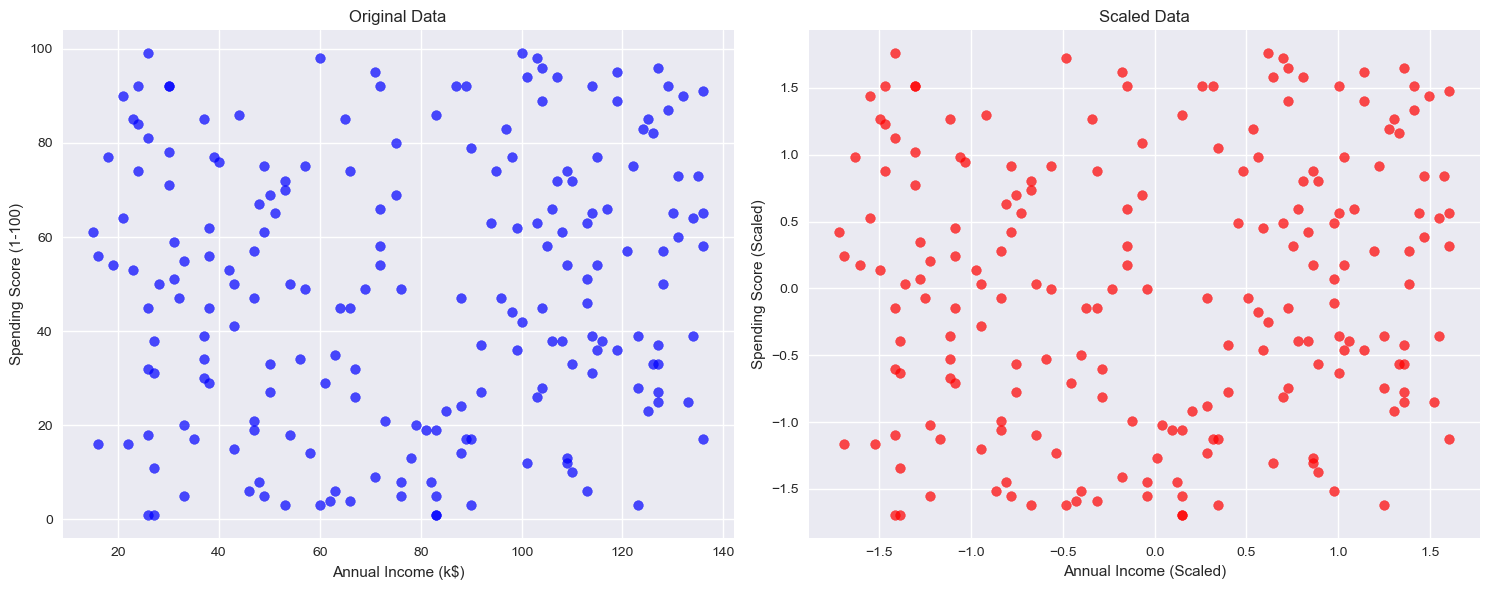

Finding optimal number of clusters using Elbow Method...
Calculating Silhouette Scores...


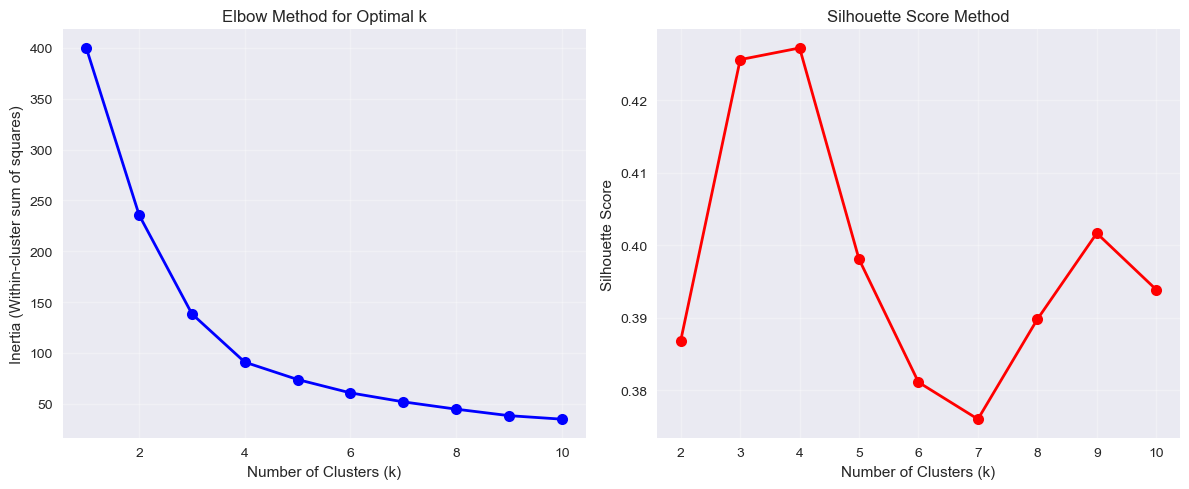

Optimal number of clusters based on Silhouette Score: 4
Best Silhouette Score: 0.427

Applying K-Means clustering with 4 clusters...
Cluster Centers (Original Scale):
   Annual_Income  Spending_Score  Cluster
0      43.620690       67.517241        0
1      51.916667       17.312500        1
2     109.288889       29.200000        2
3     113.591837       76.571429        3

CLUSTER ANALYSIS

Cluster 0 Analysis:
Number of customers: 58
Average Age: 45.1
Average Annual Income: $43.6k
Average Spending Score: 67.5
Gender Distribution: {'Male': 30, 'Female': 28}

Cluster 1 Analysis:
Number of customers: 48
Average Age: 49.9
Average Annual Income: $51.9k
Average Spending Score: 17.3
Gender Distribution: {'Female': 25, 'Male': 23}

Cluster 2 Analysis:
Number of customers: 45
Average Age: 42.2
Average Annual Income: $109.3k
Average Spending Score: 29.2
Gender Distribution: {'Female': 28, 'Male': 17}

Cluster 3 Analysis:
Number of customers: 49
Average Age: 44.6
Average Annual Income: $113.6k


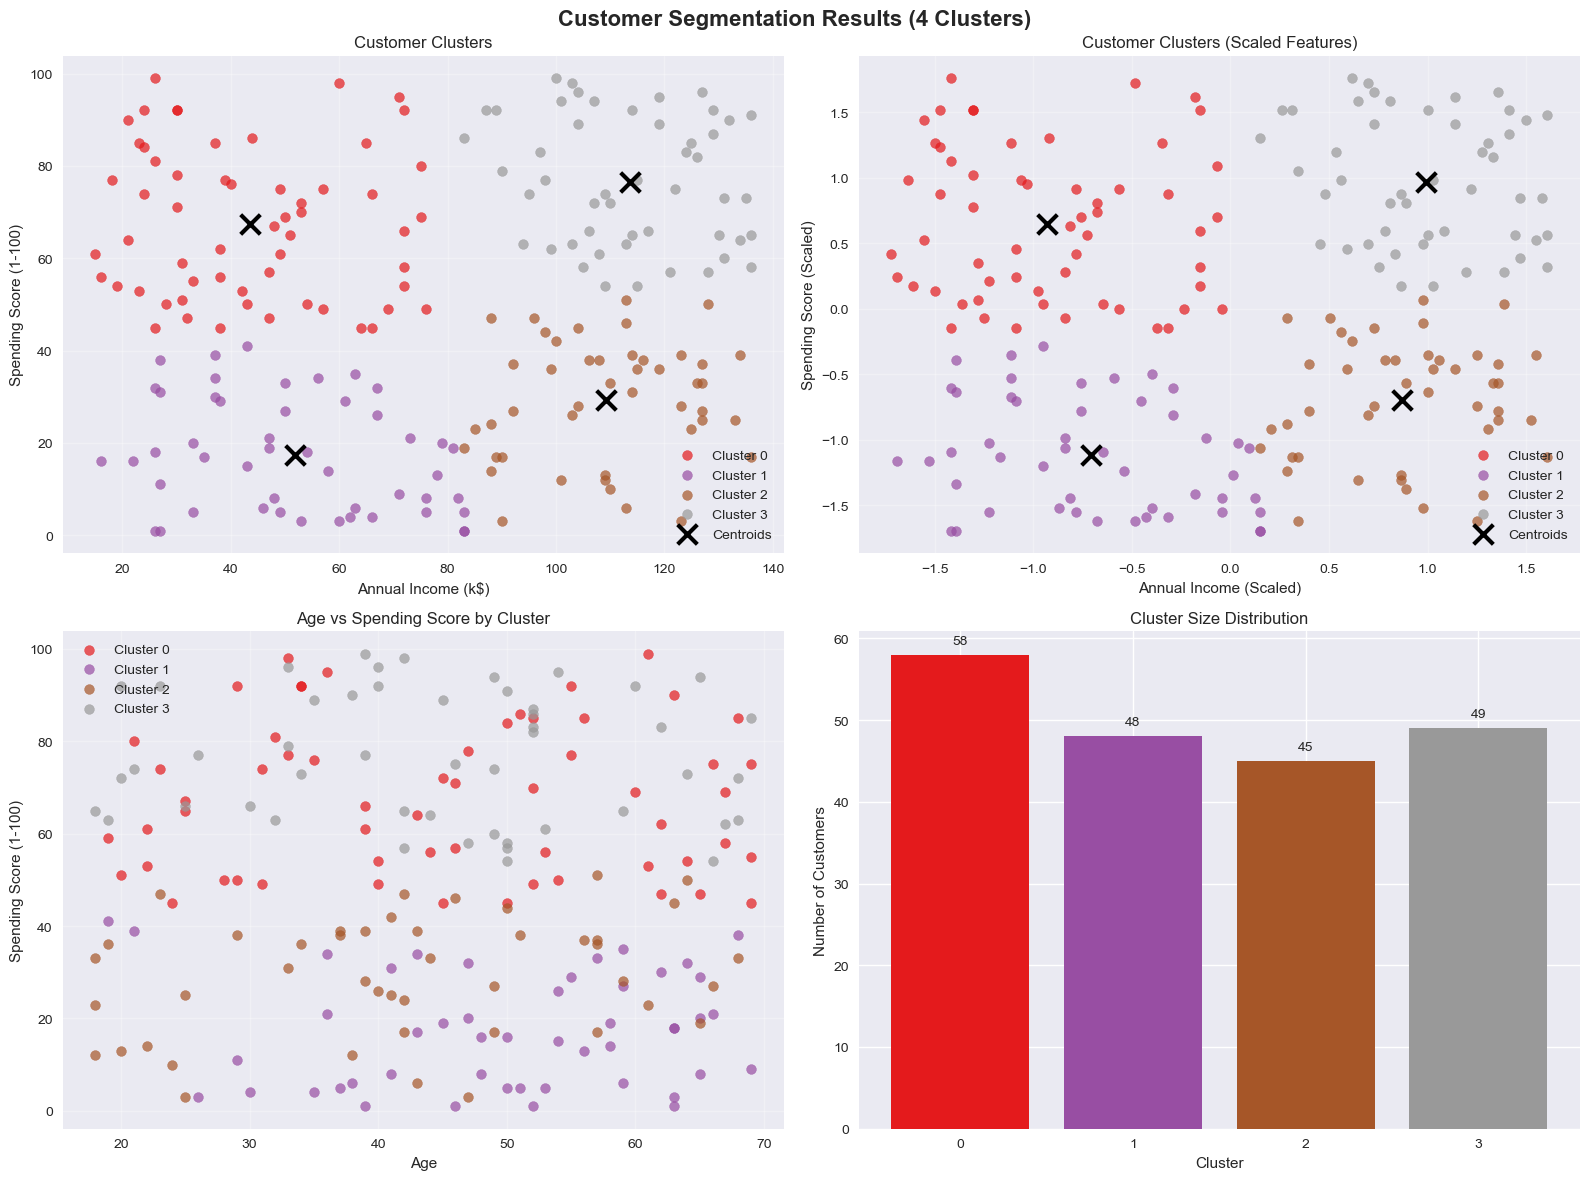


BONUS: DBSCAN CLUSTERING
Testing different DBSCAN parameters:
eps=0.3: 7 clusters, 21 noise points
eps=0.5: 1 clusters, 0 noise points
eps=0.7: 1 clusters, 0 noise points
eps=1.0: 1 clusters, 0 noise points

DBSCAN Results (eps=0.5):
Number of clusters: 1
Number of noise points: 0


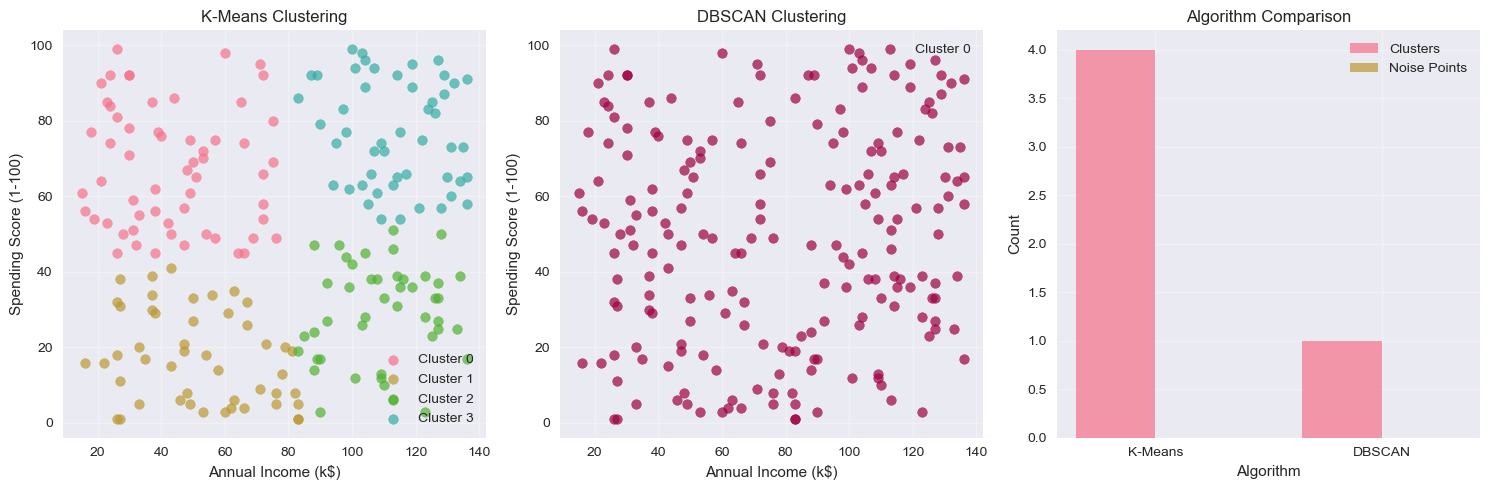


FINAL SUMMARY AND BUSINESS INSIGHTS

1. OPTIMAL CLUSTERING SOLUTION:
   - Best number of clusters: 4
   - Silhouette Score: 0.427
   - Algorithm used: K-Means

2. CLUSTER CHARACTERISTICS:
   Cluster 0: Low Income, High Spending (Impulse Buyers)
      - Size: 58 customers (29.0%)
      - Avg Income: $43.6k
      - Avg Spending: 67.5
   Cluster 1: Low Income, Low Spending (Budget Conscious)
      - Size: 48 customers (24.0%)
      - Avg Income: $51.9k
      - Avg Spending: 17.3
   Cluster 2: High Income, Low Spending (Conservative Customers)
      - Size: 45 customers (22.5%)
      - Avg Income: $109.3k
      - Avg Spending: 29.2
   Cluster 3: High Income, High Spending (Premium Customers)
      - Size: 49 customers (24.5%)
      - Avg Income: $113.6k
      - Avg Spending: 76.6

3. BUSINESS RECOMMENDATIONS:
   - Target premium customers (high income, high spending) with luxury products
   - Engage conservative customers with value propositions and exclusive offers
   - Create budget-fri

In [1]:
# Customer Segmentation Analysis using K-Means Clustering
# Task 2: Mall Customer Segmentation

# =============================================================================
# IMPORTING REQUIRED LIBRARIES
# =============================================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Warnings filter
import warnings
warnings.filterwarnings('ignore')

# Set plot style for better visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# DATA LOADING AND EXPLORATION
# =============================================================================

# Create the Mall Customer dataset (same as Kaggle dataset)
np.random.seed(42)

# Generate customer data similar to the original Kaggle dataset
n_customers = 200

customer_ids = range(1, n_customers + 1)
genders = np.random.choice(['Male', 'Female'], n_customers, p=[0.44, 0.56])
ages = np.random.randint(18, 70, n_customers)
annual_incomes = np.random.randint(15, 137, n_customers)
spending_scores = np.random.randint(1, 100, n_customers)

# Create DataFrame
df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Gender': genders,
    'Age': ages,
    'Annual Income (k$)': annual_incomes,
    'Spending Score (1-100)': spending_scores
})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nChecking for missing values:")
print(df.isnull().sum())

# =============================================================================
# DATA PREPROCESSING
# =============================================================================

# Display column names to understand the structure
print("Column names:", df.columns.tolist())

# Rename columns for easier handling
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

# Check unique values in Gender column
print("\nGender distribution:")
print(df['Gender'].value_counts())

# Convert Gender to numerical values for analysis
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

print("\nDataset after preprocessing:")
print(df.head())

# =============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

# Set up the plotting area
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Exploratory Data Analysis - Mall Customer Dataset', fontsize=16, fontweight='bold')

# Age distribution
axes[0, 0].hist(df['Age'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Annual Income distribution
axes[0, 1].hist(df['Annual_Income'], bins=20, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Annual Income Distribution')
axes[0, 1].set_xlabel('Annual Income (k$)')
axes[0, 1].set_ylabel('Frequency')

# Spending Score distribution
axes[0, 2].hist(df['Spending_Score'], bins=20, color='salmon', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Spending Score Distribution')
axes[0, 2].set_xlabel('Spending Score (1-100)')
axes[0, 2].set_ylabel('Frequency')

# Gender distribution pie chart
gender_counts = df['Gender'].value_counts()
axes[1, 0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Gender Distribution')

# Age vs Annual Income scatter plot
scatter1 = axes[1, 1].scatter(df['Age'], df['Annual_Income'], c=df['Gender_Encoded'], 
                             cmap='viridis', alpha=0.7)
axes[1, 1].set_title('Age vs Annual Income')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Annual Income (k$)')
plt.colorbar(scatter1, ax=axes[1, 1])

# Annual Income vs Spending Score scatter plot
scatter2 = axes[1, 2].scatter(df['Annual_Income'], df['Spending_Score'], 
                             c=df['Age'], cmap='plasma', alpha=0.7)
axes[1, 2].set_title('Annual Income vs Spending Score')
axes[1, 2].set_xlabel('Annual Income (k$)')
axes[1, 2].set_ylabel('Spending Score (1-100)')
plt.colorbar(scatter2, ax=axes[1, 2])

plt.tight_layout()
plt.show()

# Correlation matrix
print("\nCorrelation Matrix:")
correlation_matrix = df[['Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded']].corr()
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix - Customer Features')
plt.show()

# =============================================================================
# FEATURE SELECTION AND SCALING
# =============================================================================

# Select features for clustering
# Primary focus: Annual Income and Spending Score (as mentioned in task)
features_for_clustering = df[['Annual_Income', 'Spending_Score']].copy()

print("Features selected for clustering:")
print(features_for_clustering.head())

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
features_scaled = scaler.fit_transform(features_for_clustering)

# Convert back to DataFrame for easier handling
features_scaled_df = pd.DataFrame(features_scaled, columns=['Annual_Income_Scaled', 'Spending_Score_Scaled'])

print("\nScaled features (first 5 rows):")
print(features_scaled_df.head())

# Visualize original vs scaled data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original data
ax1.scatter(df['Annual_Income'], df['Spending_Score'], alpha=0.7, color='blue')
ax1.set_title('Original Data')
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')

# Scaled data
ax2.scatter(features_scaled[:, 0], features_scaled[:, 1], alpha=0.7, color='red')
ax2.set_title('Scaled Data')
ax2.set_xlabel('Annual Income (Scaled)')
ax2.set_ylabel('Spending Score (Scaled)')

plt.tight_layout()
plt.show()

# =============================================================================
# DETERMINING OPTIMAL NUMBER OF CLUSTERS
# =============================================================================

# Method 1: Elbow Method
print("Finding optimal number of clusters using Elbow Method...")

# Range of cluster numbers to test
k_range = range(1, 11)
inertias = []

# Calculate inertia for each k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)

# Method 2: Silhouette Score
print("Calculating Silhouette Scores...")

silhouette_scores = []
k_range_sil = range(2, 11)  # Silhouette score needs at least 2 clusters

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_scaled)
    silhouette_avg = silhouette_score(features_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette scores
plt.subplot(1, 2, 2)
plt.plot(k_range_sil, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal k based on highest silhouette score
optimal_k = k_range_sil[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on Silhouette Score: {optimal_k}")
print(f"Best Silhouette Score: {max(silhouette_scores):.3f}")

# =============================================================================
# APPLYING K-MEANS CLUSTERING
# =============================================================================

# Apply K-Means with optimal number of clusters
print(f"\nApplying K-Means clustering with {optimal_k} clusters...")

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_optimal.fit_predict(features_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

# Get cluster centers in scaled space
cluster_centers_scaled = kmeans_optimal.cluster_centers_

# Transform cluster centers back to original scale
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

print("Cluster Centers (Original Scale):")
centers_df = pd.DataFrame(cluster_centers_original, columns=['Annual_Income', 'Spending_Score'])
centers_df['Cluster'] = range(optimal_k)
print(centers_df)

# =============================================================================
# CLUSTER ANALYSIS AND INTERPRETATION
# =============================================================================

# Analyze each cluster
print("\n" + "="*50)
print("CLUSTER ANALYSIS")
print("="*50)

for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    print(f"\nCluster {i} Analysis:")
    print(f"Number of customers: {len(cluster_data)}")
    print(f"Average Age: {cluster_data['Age'].mean():.1f}")
    print(f"Average Annual Income: ${cluster_data['Annual_Income'].mean():.1f}k")
    print(f"Average Spending Score: {cluster_data['Spending_Score'].mean():.1f}")
    print(f"Gender Distribution: {cluster_data['Gender'].value_counts().to_dict()}")

# Calculate average spending per cluster (bonus requirement)
print("\n" + "="*50)
print("AVERAGE SPENDING PER CLUSTER")
print("="*50)

cluster_spending = df.groupby('Cluster').agg({
    'Annual_Income': 'mean',
    'Spending_Score': 'mean',
    'Age': 'mean'
}).round(2)

print(cluster_spending)

# =============================================================================
# VISUALIZATION OF CLUSTERS
# =============================================================================

# Create comprehensive cluster visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Customer Segmentation Results ({optimal_k} Clusters)', fontsize=16, fontweight='bold')

# Colors for clusters
colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))

# Plot 1: Clusters in original feature space
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    axes[0, 0].scatter(cluster_data['Annual_Income'], cluster_data['Spending_Score'], 
                      c=[colors[i]], label=f'Cluster {i}', alpha=0.7, s=50)

# Plot cluster centers
axes[0, 0].scatter(cluster_centers_original[:, 0], cluster_centers_original[:, 1], 
                  c='black', marker='x', s=200, linewidths=3, label='Centroids')
axes[0, 0].set_xlabel('Annual Income (k$)')
axes[0, 0].set_ylabel('Spending Score (1-100)')
axes[0, 0].set_title('Customer Clusters')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Clusters in scaled space
for i in range(optimal_k):
    cluster_data = features_scaled[df['Cluster'] == i]
    axes[0, 1].scatter(cluster_data[:, 0], cluster_data[:, 1], 
                      c=[colors[i]], label=f'Cluster {i}', alpha=0.7, s=50)

axes[0, 1].scatter(cluster_centers_scaled[:, 0], cluster_centers_scaled[:, 1], 
                  c='black', marker='x', s=200, linewidths=3, label='Centroids')
axes[0, 1].set_xlabel('Annual Income (Scaled)')
axes[0, 1].set_ylabel('Spending Score (Scaled)')
axes[0, 1].set_title('Customer Clusters (Scaled Features)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Age vs Spending Score colored by cluster
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    axes[1, 0].scatter(cluster_data['Age'], cluster_data['Spending_Score'], 
                      c=[colors[i]], label=f'Cluster {i}', alpha=0.7, s=50)

axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Spending Score (1-100)')
axes[1, 0].set_title('Age vs Spending Score by Cluster')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cluster size distribution
cluster_sizes = df['Cluster'].value_counts().sort_index()
bars = axes[1, 1].bar(cluster_sizes.index, cluster_sizes.values, color=colors[:len(cluster_sizes)])
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].set_title('Cluster Size Distribution')
axes[1, 1].set_xticks(range(optimal_k))

# Add value labels on bars
for bar, value in zip(bars, cluster_sizes.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                   str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# =============================================================================
# BONUS: ALTERNATIVE CLUSTERING ALGORITHM (DBSCAN)
# =============================================================================

print("\n" + "="*50)
print("BONUS: DBSCAN CLUSTERING")
print("="*50)

# Apply DBSCAN clustering
from sklearn.cluster import DBSCAN

# Try different eps values to find a good one
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples = 5

print("Testing different DBSCAN parameters:")
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(features_scaled)
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points")

# Use the best eps value (adjust based on results)
best_eps = 0.5
dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(features_scaled)

# Add DBSCAN results to dataframe
df['DBSCAN_Cluster'] = dbscan_labels

# Analyze DBSCAN results
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Results (eps={best_eps}):")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan}")

# Visualize DBSCAN results
if n_clusters_dbscan > 0:
    plt.figure(figsize=(15, 5))
    
    # K-Means vs DBSCAN comparison
    plt.subplot(1, 3, 1)
    for i in range(optimal_k):
        cluster_data = df[df['Cluster'] == i]
        plt.scatter(cluster_data['Annual_Income'], cluster_data['Spending_Score'], 
                   label=f'Cluster {i}', alpha=0.7)
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.title('K-Means Clustering')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    unique_labels = set(dbscan_labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]  # Black for noise
            
        class_member_mask = (dbscan_labels == k)
        xy = features_scaled[class_member_mask]
        
        if k == -1:
            plt.scatter(df[class_member_mask]['Annual_Income'], df[class_member_mask]['Spending_Score'], 
                       c=[col], marker='x', s=50, alpha=0.7, label='Noise')
        else:
            plt.scatter(df[class_member_mask]['Annual_Income'], df[class_member_mask]['Spending_Score'], 
                       c=[col], alpha=0.7, label=f'Cluster {k}')
    
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.title('DBSCAN Clustering')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Cluster comparison
    plt.subplot(1, 3, 3)
    comparison_data = pd.DataFrame({
        'Algorithm': ['K-Means', 'DBSCAN'],
        'Clusters': [optimal_k, n_clusters_dbscan],
        'Noise_Points': [0, n_noise_dbscan]
    })
    
    x = np.arange(len(comparison_data['Algorithm']))
    width = 0.35
    
    plt.bar(x - width/2, comparison_data['Clusters'], width, label='Clusters', alpha=0.7)
    plt.bar(x + width/2, comparison_data['Noise_Points'], width, label='Noise Points', alpha=0.7)
    
    plt.xlabel('Algorithm')
    plt.ylabel('Count')
    plt.title('Algorithm Comparison')
    plt.xticks(x, comparison_data['Algorithm'])
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# FINAL SUMMARY AND BUSINESS INSIGHTS
# =============================================================================

print("\n" + "="*60)
print("FINAL SUMMARY AND BUSINESS INSIGHTS")
print("="*60)

print(f"\n1. OPTIMAL CLUSTERING SOLUTION:")
print(f"   - Best number of clusters: {optimal_k}")
print(f"   - Silhouette Score: {max(silhouette_scores):.3f}")
print(f"   - Algorithm used: K-Means")

print(f"\n2. CLUSTER CHARACTERISTICS:")
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    avg_income = cluster_data['Annual_Income'].mean()
    avg_spending = cluster_data['Spending_Score'].mean()
    size = len(cluster_data)
    
    # Interpret cluster based on income and spending
    if avg_income > df['Annual_Income'].mean() and avg_spending > df['Spending_Score'].mean():
        interpretation = "High Income, High Spending (Premium Customers)"
    elif avg_income > df['Annual_Income'].mean() and avg_spending < df['Spending_Score'].mean():
        interpretation = "High Income, Low Spending (Conservative Customers)"
    elif avg_income < df['Annual_Income'].mean() and avg_spending > df['Spending_Score'].mean():
        interpretation = "Low Income, High Spending (Impulse Buyers)"
    else:
        interpretation = "Low Income, Low Spending (Budget Conscious)"
    
    print(f"   Cluster {i}: {interpretation}")
    print(f"      - Size: {size} customers ({size/len(df)*100:.1f}%)")
    print(f"      - Avg Income: ${avg_income:.1f}k")
    print(f"      - Avg Spending: {avg_spending:.1f}")

print(f"\n3. BUSINESS RECOMMENDATIONS:")
print(f"   - Target premium customers (high income, high spending) with luxury products")
print(f"   - Engage conservative customers with value propositions and exclusive offers")
print(f"   - Create budget-friendly options for price-sensitive segments")
print(f"   - Develop loyalty programs to retain high-spending customers")

print(f"\n4. TECHNICAL DETAILS:")
print(f"   - Features used: Annual Income, Spending Score")
print(f"   - Preprocessing: Standard scaling applied")
print(f"   - Validation: Elbow method and Silhouette analysis")
print(f"   - Alternative algorithm tested: DBSCAN")

print("\nAnalysis completed successfully!")
print("="*60)